# Predicting loan approval with k-Nearest Neighbors


# Objectives

Build a k-Nearest Neighbors classifier from scratch using a small 2D approval dataset and learn how kNN works geometrically.

1. Define a 2D dataset with two features (`income`, `credit_score`).
2. Inspect the shapes of input and output arrays.
3. Plot the training data in 2D feature space.
4. Fit kNN classifiers for `k=1` and `k=2`.
5. Predict the class of a new customer.
6. Visualize the decision regions in 2D.
7. Explore how changing `k` affects the decision boundary.

Along the way, you will also pick up:
- Using `numpy` arrays for feature matrices and label vectors.
- Using `np.meshgrid` to create a 2D grid for visualization.
- Plotting decision regions with `plt.contourf`.
- Understanding overfitting vs. underfitting through the valueof `k`.

# Predicting loan approval in 2D

A bank wants to decide whether to approve a loan based on two input features:
- annual income (in $10,000s)
- credit score (scaled from 0 to 10)

You are given past data:

| income | credit_score | approval |
|--------|--------------|----------|
| 2      | 3            | 0        |
| 2      | 5            | 0        |
| 3      | 4            | 0        |
| 4      | 4            | 1        |
| 5      | 6            | 1        |
| 6      | 5            | 1        |

Where:
- approval = 0  -> denied
- approval = 1 -> approved

# Predictive question

A new customer has
- income = 4
- credit score = 5

Will the loan be approved?

# Coding Tasks

To answer the question, follow this workflow:

1. Import required libraries
2. Define the 2D dataset
3. Inspect the shapes of input and output
4. Plot the training data
5. Fit and predict `model1` for `k=1`
6. Fit and predict `model2` for `k=3`
7. Compare the predictions
8. Visualize the decision regions

# 1. Import required libraries

Import the `KNeighborsClassifier` class from the `neighbors` module of the `sklearn` library with the alias `knn` ([find out more here](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)).

In [14]:
from sklearn.neighbors import KNeighborsClassifier as knn

Import the numeric library `numpy` with the alias `np`.

In [15]:
import numpy as np

For visualization, import the `pyplot` module from the `matplotlib` library with the alias `plt`.

In [16]:
import matplotlib.pyplot as plt

# 2. Define the dataset

We have two features, `income` and `credit_score`. The classifier expects input in array format. The `np.array()` function stores these as a 2D
array or matrix.

Example:

In [17]:
l = [ [1,2], [3,4]] # a list with two list members
print(l) # prints as a list
print(np.array(l)) # prints as a matrix
print(np.array(l)[1,1]) # prints matrix element [1,1]

[[1, 2], [3, 4]]
[[1 2]
 [3 4]]
4


Create a matrix (2d array) `X` for the observations from the table. It contains the input features.

In [18]:
# Input features: [income, credit_score]
X = np.array([
    [2,3],
    [2,5],
    [3,4],
    [4,4],
    [5,6],
    [6,5]
])

Create a vector (1d array) for the target labels also sourced from the table. It contains the (known) output feature.

In [19]:
# Output labels: 0 = denied, 1 = approved
y = np.array([0,0,0,1,1,1])

Create a new customer `x_new` with $40,000 income and a credit score of 5.

In [21]:
# New customer
x_new = np.array([[4,5]])
print(x_new)

[[4 5]]


# 3. Inspect the shapes of input and output

`sklearn` expects 2D input. Let's check the shape of our objects before plotting and building the model.

In [25]:
print("Input features (X) shape: ", X.shape) # 6 x 2 array
print("Output label (y) shape: ", y.shape) # 6 x 1 array
print("New input features (x_new) shape: ", x_new.shape) # 1 x 2 array

Input features (X) shape:  (6, 2)
Output label (y) shape:  (6,)
New input features (x_new) shape:  (1, 2)


If your `x_new` shape is not a 2D array but a list, you'll get an error later:

In [27]:
foo = np.array([4,5])
print(foo.shape)
bar = np.array([[4,5]])
print(bar.shape)

(2,)
(1, 2)


# 4. Plot the training data

We use the `plt` method `scatter` to generate a scatterplot of the loan approval training data and the new data point.

In the second step, we customize the plot to make it more readable/presentable.

Each data point is an (x,y) point in the plane. The indexing logic is the tricky part:
- `y==0` produces a boolean mask

In [28]:
print(y)
print(y==0)

[0 0 0 1 1 1]
[ True  True  True False False False]


- `X[y==0]` goes through each row of `X` and selects the values where the label is 0 ('denied').

In [32]:
print(X)
print('loan denied:\n', X[y==0])

[[2 3]
 [2 5]
 [3 4]
 [4 4]
 [5 6]
 [6 5]]
loan denied:
 [[2 3]
 [2 5]
 [3 4]]


- Adding the column index 0 picks column 0 (`income`) from those rows: these become the x-axis values.

In [33]:
print(X[y==0,0]) # income for denied loans -> x-axis

[2 2 3]


- Adding the column index 1 picks column 1 (`credit_score`) from those rows: these become the y-axis values.

In [34]:
print(X[y==0,1]) # credit score for denied loans -> y-axis

[3 5 4]


This pattern is repeated for approved loans. Let's put this together for the plot:

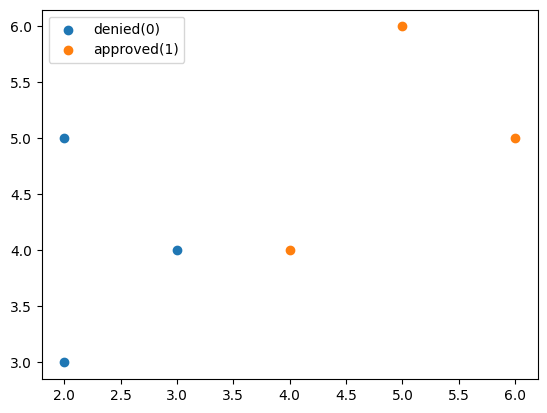

In [36]:
plt.clf() # clean graphics

plt.scatter(X[y==0,0], X[y==0,1], label="denied(0)") # denied loans
plt.scatter(X[y==1,0], X[y==1,1], label="approved(1)") # approved loans

plt.legend()
plt.show()

Use this code block to add the new customer. Mark it with an `x` and increase its size with `s=100`.

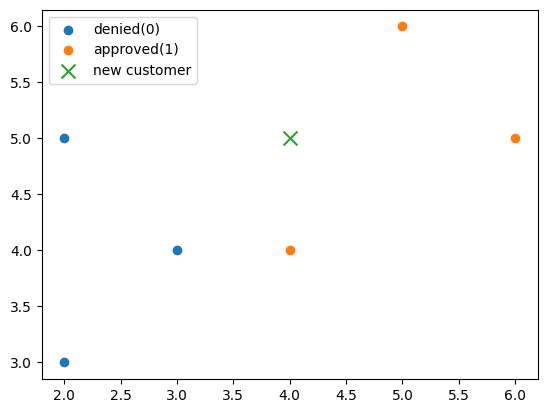

In [37]:
plt.clf() # clean graphics

plt.scatter(X[y==0,0], X[y==0,1], label="denied(0)") # denied loans
plt.scatter(X[y==1,0], X[y==1,1], label="approved(1)") # approved loans
plt.scatter(x_new[:,0],x_new[:,1],marker='x',s=100,label="new customer")

plt.legend()
plt.show()

This visualizes already which neighborhood the new customer is in - the distance to the approved loans is visibly smaller than to the denied loans.

Lastly, customize the plot - we're going to use this later when we draw the decision boundary.

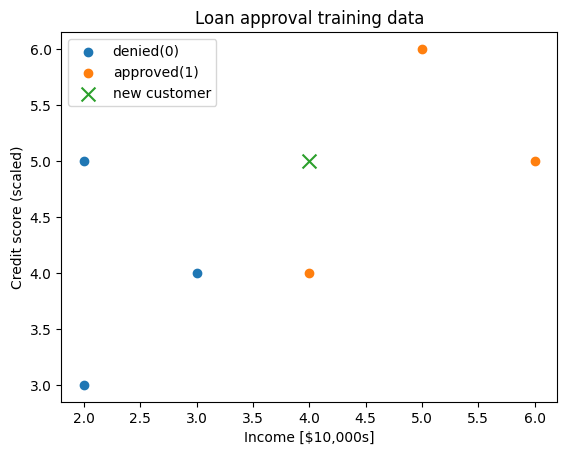

In [38]:
plt.clf() # clean graphics

plt.scatter(X[y==0,0], X[y==0,1], label="denied(0)") # denied loans
plt.scatter(X[y==1,0], X[y==1,1], label="approved(1)") # approved loans
plt.scatter(x_new[:,0],x_new[:,1],marker='x',s=100,label="new customer")

plt.xlabel("Income [$10,000s]")
plt.ylabel("Credit score (scaled)")
plt.title("Loan approval training data")
plt.legend()
plt.show()

# 5. Fit and predict `model1` for `k=1`

To build `model1`, we only need to call `knn` (the classifier) and specify `k`, the number of nearest neighbors to be taken into account later.

In [40]:
model1 = knn(n_neighbors=1)

To fit the model, we call `knn.fit()` on `model1`. The classifier has now memorized the geometric properties of our dataset.

In [41]:
model1.fit(X,y)

KNeighborsClassifier(n_neighbors=1)

- To make a prediction, we run `knn.predict()` on our new, unseen data
  in `x_new`.


In [43]:
pred1 = model1.predict(x_new)
print(pred1)

[1]


Why does this print as `[1]`?

**Answer:** Because `model.predict()` always returns a 1D array and not a scalar (number) even when predicting a single point.

In [44]:
print(pred1[0])

1


# 6. Fit and predict `model3` for `k=3`

Same process with only a change for the choice of `k`.

In [51]:
model3 = knn(n_neighbors=3)
model3.fit(X,y)
pred3 = model3.predict(x_new)
print(pred3)

[1]


What if you were to change the value of k to 6? What if you were to change it to 7?

**Answer:** for `k=6` you would get the prediction 'loan denied' (0). Now the result isn't about distance anymore but just a vote across the entire dataset.

Both groups yield the same number of votes, so we have a 3:3 tie. scikit-learn breaks that tie by picking the first index with the maximum count.

# 7. Compare the predictions

Do the predictions differ? Why or why not?

**Answer:** In this example, both `k=1` and `k=3` predict approval. The new customer is located near points labeled 1, so both the closest single neighbor and the majority of the three nearest neighbors vote for approval.

# 8. Visualize decision regions

To understand how the model generalizes beyond the training points, we can visualize the decision regions — the areas of the 2D feature space that the model would classify as approved or denied for any hypothetical customer, not just the six we trained on.

The idea is to create a fine grid of points covering the entire income/credit-score plane, predict the class for each grid point, and color the plane accordingly. Where the color changes is the decision boundary — the line (or curve) separating the two regions.

We do this in three steps:
1. Build a dense 2D grid with `np.meshgrid`
2. Run `model.predict()` on every grid point
3. Plot the colored regions with `plt.contourf`, then overlay the training points and new customer.

Copy the last code block for the data visualization and modify it here:

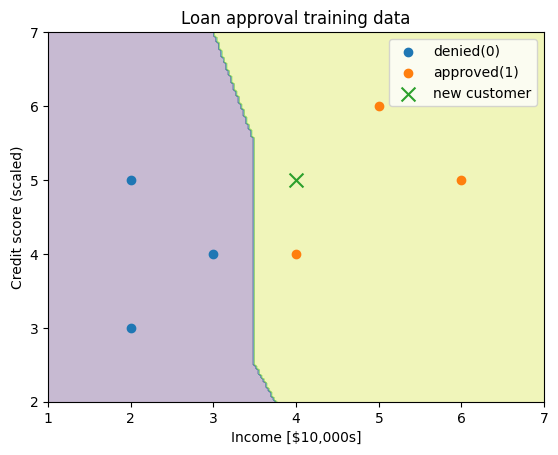

In [54]:
plt.clf() # clean graphics

#---- pick model
model = model1

#---- create 200 x 200 mesh grid
xx, yy = np.meshgrid(
    np.linspace(1,7,200),  # 200 evenly spaced x-values
    np.linspace(2,7,200)   # 200 evenly spaced y-values
)

#---- create input shapes that scikit-learn expects
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid). reshape(xx.shape)

#---- draw filled color regions and color according to the Z value
plt.contourf(xx,yy,Z,alpha=0.3)

plt.scatter(X[y==0,0], X[y==0,1], label="denied(0)") # denied loans
plt.scatter(X[y==1,0], X[y==1,1], label="approved(1)") # approved loans
plt.scatter(x_new[:,0],x_new[:,1],marker='x',s=100,label="new customer")

plt.xlabel("Income [$10,000s]")
plt.ylabel("Credit score (scaled)")
plt.title("Loan approval training data")
plt.legend()
plt.show()

*Code explanation:*

- `plt.clf()`: Clear the current figure to start with a fresh plot.
- `model = model1`: Select which trained kNN model to visualize (here: k = 1).
- `np.meshgrid(...)`: Create a grid of evenly spaced points covering the 2D feature space.
- `xx, yy`: Matrices representing all x- and y-coordinates in the grid.
- `xx.ravel(), yy.ravel()`: Flatten the grid into 1D arrays.
- `np.c_[...]`: Combine flattened x and y into a list of coordinate pairs — shape `(num_points, 2)`.
- `model.predict(grid)`: Predict class (0 or 1) for every point in the grid.
- `reshape(xx.shape)`: Convert predictions back into grid shape for plotting.
- `plt.contourf(xx, yy, Z, alpha=0.3)`: Draw filled regions showing predicted class across the plane.
